# Angie Crews
## Phase 5 Custom Project and Engage 

This notebook documents the Phase 5 custom NLP pipeline work using a new arXiv paper: *Attention Is All You Need*.

Goals:
- run the custom Angie pipeline
- inspect the processed CSV results
- review the generated visual outputs
- summarize insights for submission

## 1. Environment and Imports
This notebook uses pandas and standard library tools to inspect the custom Phase 5 outputs.

In [4]:
from pathlib import Path
import subprocess
import sys

from IPython.display import Image, Markdown, display
import pandas as pd

In [5]:
ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == 'notebooks'
    else Path.cwd().resolve()
)
DATA_PROCESSED = ROOT / 'data' / 'processed'
CSV_PATH = DATA_PROCESSED / 'angie_phase5_processed.csv'
TOP_TOKENS_PATH = DATA_PROCESSED / 'angie_phase5_top_tokens.png'
WORDCLOUD_PATH = DATA_PROCESSED / 'angie_phase5_wordcloud.png'
SENTENCE_LENGTHS_PATH = DATA_PROCESSED / 'angie_phase5_sentence_lengths.png'

ROOT, CSV_PATH

(WindowsPath('C:/Repos/nlp-06-nlp-pipeline'),
 WindowsPath('C:/Repos/nlp-06-nlp-pipeline/data/processed/angie_phase5_processed.csv'))

## 2. Run the Custom Pipeline
This cell reruns the custom Angie pipeline so the notebook reflects the latest results.

In [7]:
import os

python_executable = ROOT / '.venv' / 'Scripts' / 'python.exe'
python_cmd = str(python_executable) if python_executable.exists() else sys.executable

env = os.environ.copy()
existing_pythonpath = env.get('PYTHONPATH', '')
src_path = str(ROOT / 'src')
env['PYTHONPATH'] = (
    src_path if not existing_pythonpath else src_path + os.pathsep + existing_pythonpath
)
env['MPLBACKEND'] = 'agg'

result = subprocess.run(
    [python_cmd, '-m', 'nlp.pipeline_web_html_angie'],
    cwd=ROOT,
    capture_output=True,
    text=True,
    env=env,
)

print(f'Return code: {result.returncode}')
if result.stdout:
    print('STDOUT:')
    print(result.stdout[-4000:])
if result.stderr:
    print('STDERR:')
    print(result.stderr[-4000:])

if result.returncode != 0:
    raise RuntimeError('Pipeline execution failed. Review STDERR above for details.')

Return code: 0
STDERR:
ns
2026-04-07 18:54:38 | INFO | CI | Columns: ['arxiv_id', 'title', 'authors', 'subjects', 'submitted', 'abstract_raw', 'abstract_clean', 'tokens', 'abstract_word_count', 'token_count', 'unique_token_count', 'type_token_ratio', 'author_count', 'sentence_count', 'avg_sentence_length_words', 'sentence_lengths']
2026-04-07 18:54:38 | INFO | CI |   DF preview:
     arxiv_id  ... avg_sentence_length_words
0  1706.03762  ...                     24.14

[1 rows x 5 columns]
2026-04-07 18:54:38 | INFO | CI | Sink: Pandas DataFrame created
2026-04-07 18:54:38 | INFO | CI | Transformation complete.
2026-04-07 18:54:38 | INFO | CI | ========================
2026-04-07 18:54:38 | INFO | CI | STAGE 04: ANALYZE starting...
2026-04-07 18:54:38 | INFO | CI | ========================
2026-04-07 18:54:38 | INFO | CI |   Paper: Attention Is All You Need
2026-04-07 18:54:38 | INFO | CI |   Abstract word count (raw):    166
2026-04-07 18:54:38 | INFO | CI |   Token count (clean):     

## 3. Inspect the Processed Results
Load the custom Phase 5 CSV and review the key columns.

In [8]:
df = pd.read_csv(CSV_PATH)
df

,arxiv_id,title,authors,subjects,submitted,abstract_raw,abstract_clean,tokens,abstract_word_count,token_count,unique_token_count,type_token_ratio,author_count,sentence_count,avg_sentence_length_words,sentence_lengths
0,1706.03762,Attention Is All You Need,"Ashish Vaswani, Noam Shazeer, Niki Parmar, Jak...",Computer Science > Computation and Language,"[Submitted on 12 Jun 2017 (v1), last revised 2...",The dominant sequence transduction models are ...,dominant sequence transduction models based co...,dominant sequence transduction models based co...,166,99,79,0.798,8,7,24.14,19;14;20;25;23;43;25


In [9]:
summary_columns = [
    'title',
    'subjects',
    'abstract_word_count',
    'token_count',
    'unique_token_count',
    'type_token_ratio',
    'author_count',
    'sentence_count',
    'avg_sentence_length_words',
    'sentence_lengths',
]
df[summary_columns]

,title,subjects,abstract_word_count,token_count,unique_token_count,type_token_ratio,author_count,sentence_count,avg_sentence_length_words,sentence_lengths
0,Attention Is All You Need,Computer Science > Computation and Language,166,99,79,0.798,8,7,24.14,19;14;20;25;23;43;25


## 4. Display the Visual Outputs
These are the generated Phase 5 analysis artifacts.

### Top Tokens

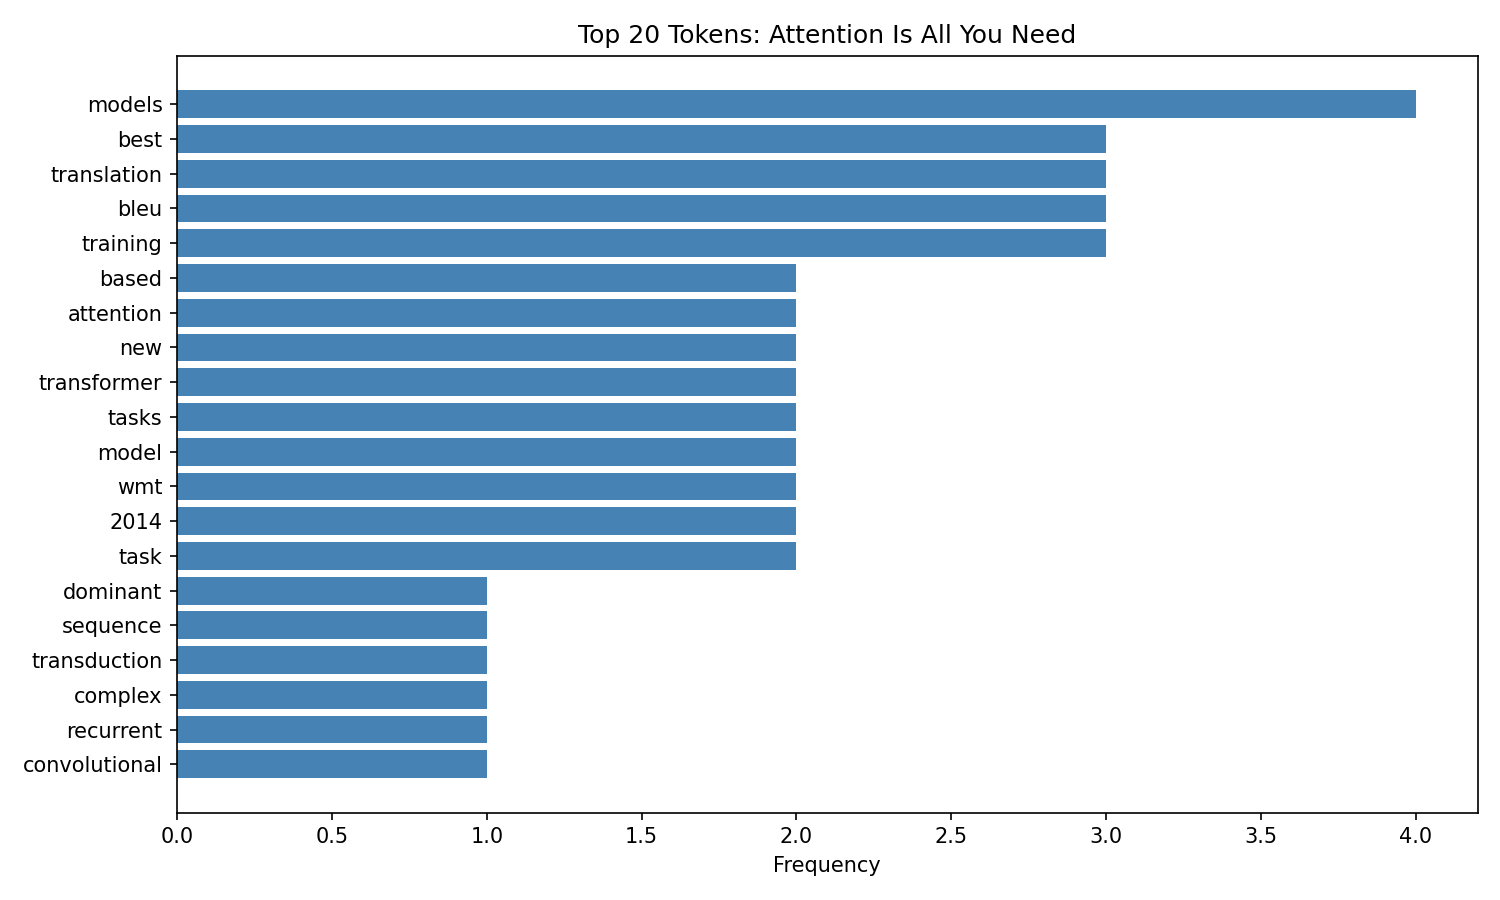

### Word Cloud

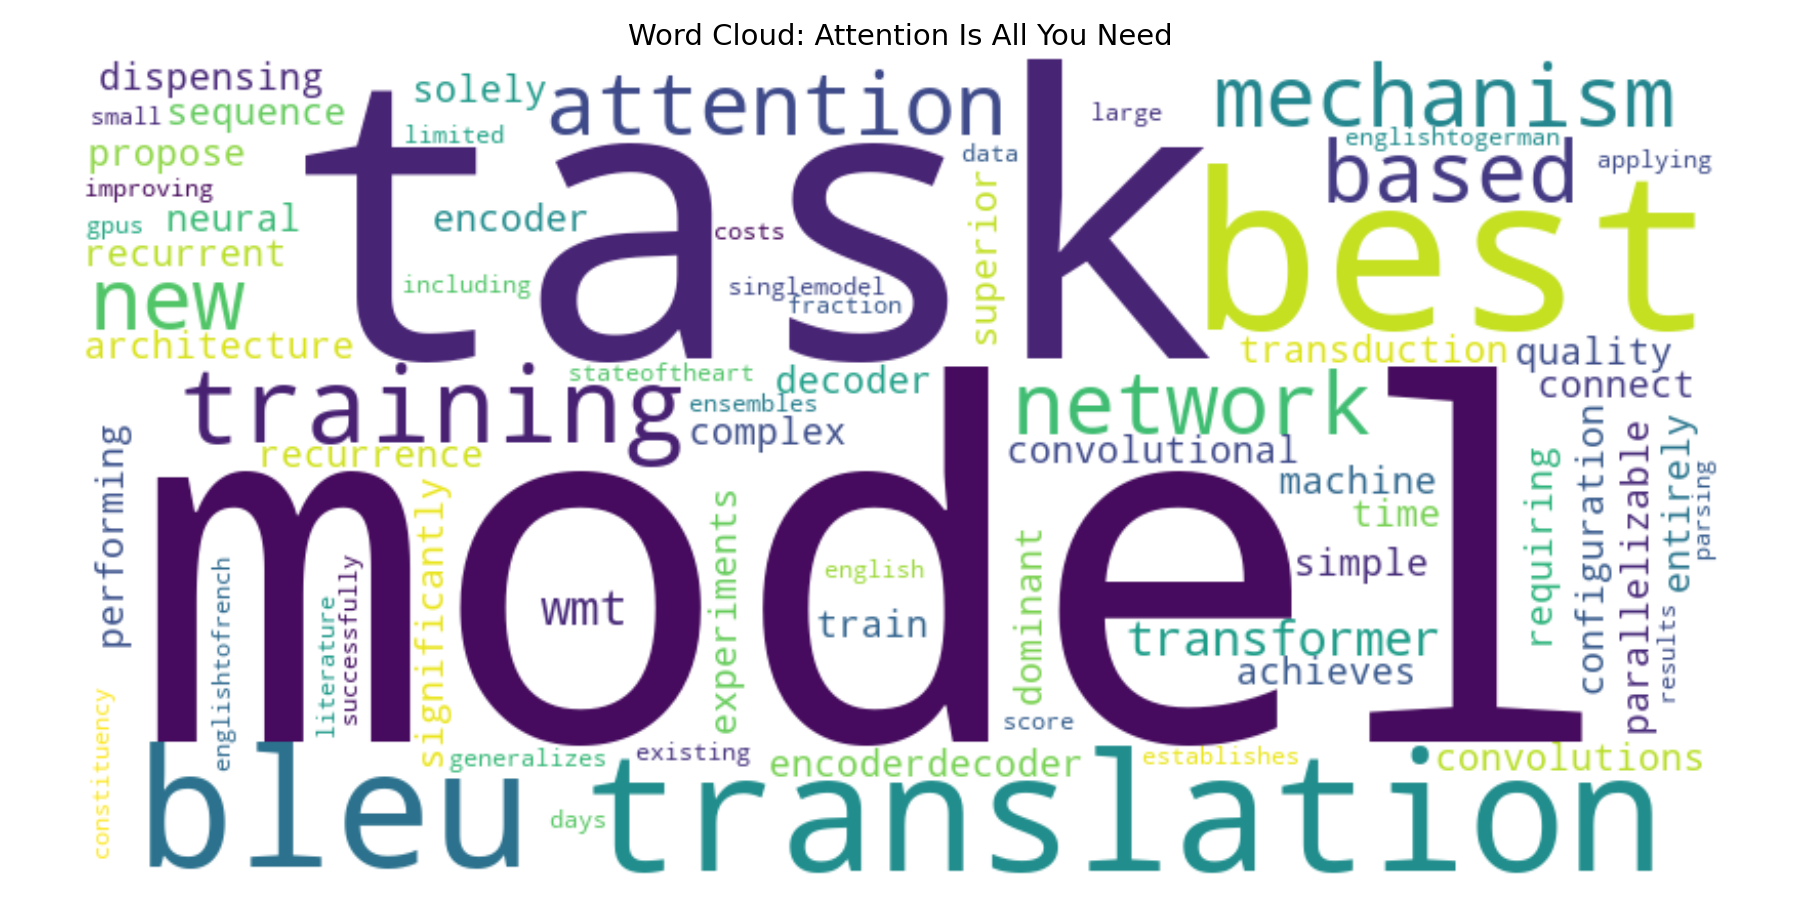

### Sentence Length Histogram

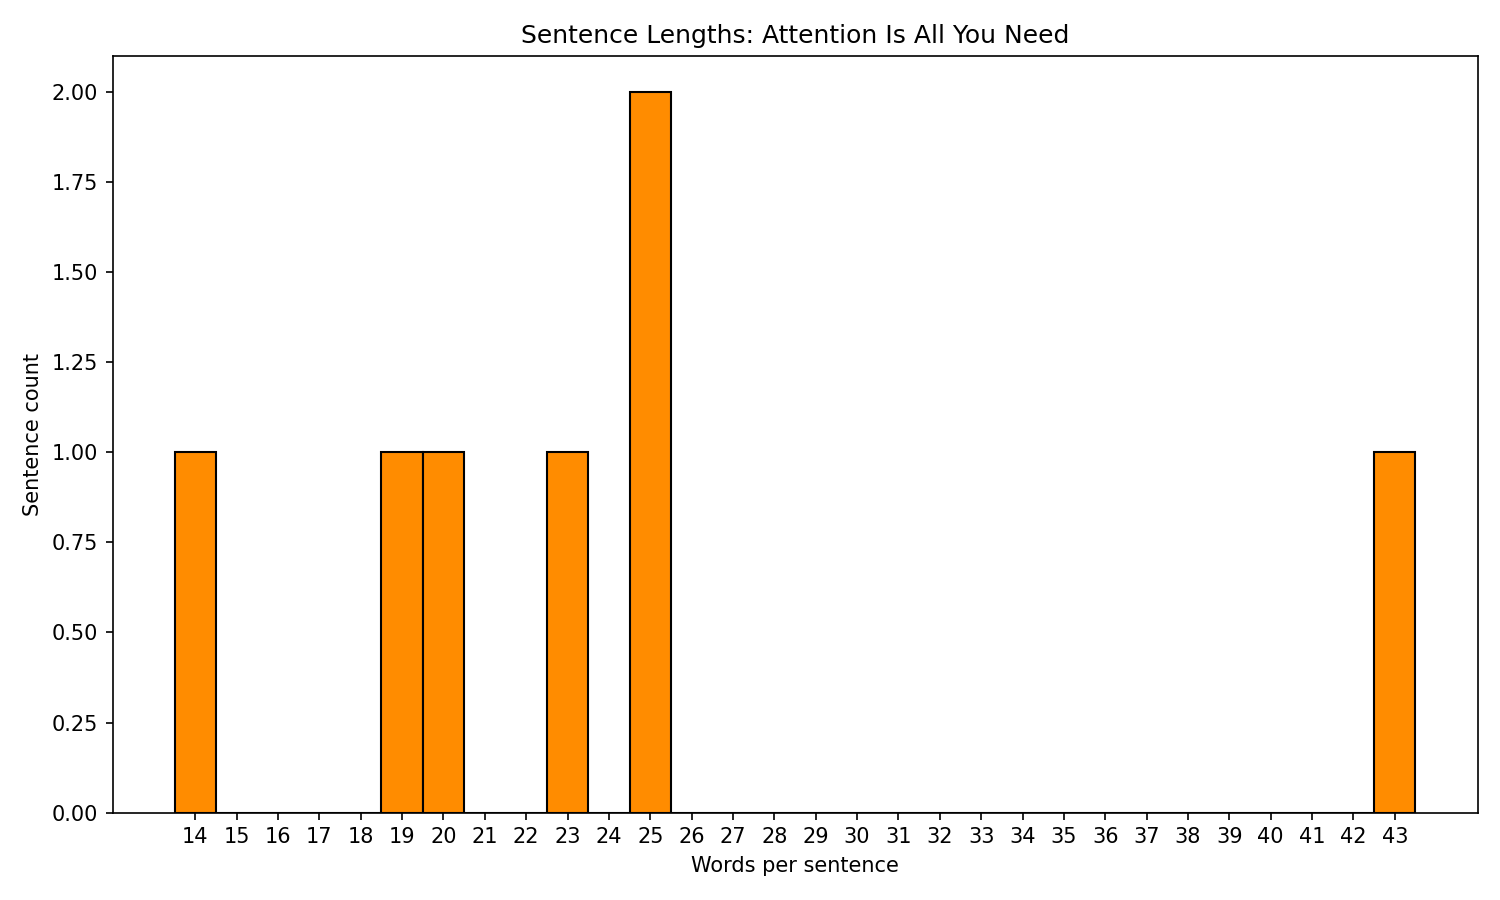

In [10]:
display(Markdown('### Top Tokens'))
display(Image(filename=str(TOP_TOKENS_PATH)))

display(Markdown('### Word Cloud'))
display(Image(filename=str(WORDCLOUD_PATH)))

display(Markdown('### Sentence Length Histogram'))
display(Image(filename=str(SENTENCE_LENGTHS_PATH)))

## 4b. Review the Processed Folder
Use this section to verify which custom Phase 5 files were created in `data/processed`. 

In [12]:
processed_files = sorted(DATA_PROCESSED.glob('*'))
phase5_files = [path for path in processed_files if 'phase5' in path.name]

for path in phase5_files:
    size_kb = path.stat().st_size / 1024
    print(f'{path.name:35} {size_kb:8.1f} KB')

angie_phase5_processed.csv               3.3 KB
angie_phase5_sentence_lengths.png       36.7 KB
angie_phase5_top_tokens.png             49.9 KB
angie_phase5_wordcloud.png             563.3 KB


## 5. Submission Answers
Use the generated values below to support the Phase 5 response prompts.

In [11]:
row = df.iloc[0]
print(f"Paper: {row['title']}")
print(f"Subject: {row['subjects']}")
print(f"Raw abstract words: {row['abstract_word_count']}")
print(f"Clean token count: {row['token_count']}")
print(f"Unique tokens: {row['unique_token_count']}")
print(f"Type-token ratio: {row['type_token_ratio']}")
print(f"Author count: {row['author_count']}")
print(f"Sentence count: {row['sentence_count']}")
print(f"Average sentence length: {row['avg_sentence_length_words']}")
print(f"Sentence lengths: {row['sentence_lengths']}")

Paper: Attention Is All You Need
Subject: Computer Science > Computation and Language
Raw abstract words: 166
Clean token count: 99
Unique tokens: 79
Type-token ratio: 0.798
Author count: 8
Sentence count: 7
Average sentence length: 24.14
Sentence lengths: 19;14;20;25;23;43;25


## 5b. Brief Results Summary
This section formats the main Phase 5 results into a short submission-ready summary. 

In [13]:
summary_text = (
    f"The custom Angie pipeline ran successfully on '{row['title']}' and produced "
    f"Phase 5 outputs including a processed CSV, top-token chart, word cloud, and "
    f"sentence-length histogram. The abstract contains {row['abstract_word_count']} raw words, "
    f"{row['token_count']} cleaned tokens, {row['unique_token_count']} unique tokens, "
    f"a type-token ratio of {row['type_token_ratio']}, {row['sentence_count']} sentences, "
    f"and an average sentence length of {row['avg_sentence_length_words']} words. "
    f"The results highlight themes such as attention, translation, models, BLEU scores, "
    f"and training efficiency."
)

display(Markdown(summary_text))

The custom Angie pipeline ran successfully on 'Attention Is All You Need' and produced Phase 5 outputs including a processed CSV, top-token chart, word cloud, and sentence-length histogram. The abstract contains 166 raw words, 99 cleaned tokens, 79 unique tokens, a type-token ratio of 0.798, 7 sentences, and an average sentence length of 24.14 words. The results highlight themes such as attention, translation, models, BLEU scores, and training efficiency.

## 6. Reflection
This custom application applies the same EVTAL workflow to a different arXiv paper and shows how the outputs shift when the input document changes. The results emphasize themes like attention, translation, models, BLEU scores, and training efficiency. The sentence-length histogram adds a structural view of the abstract, showing that the paper mixes medium-length technical statements with one especially long, information-dense sentence.